# Week 02: Statistics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [2]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [3]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_1083/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_1083/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


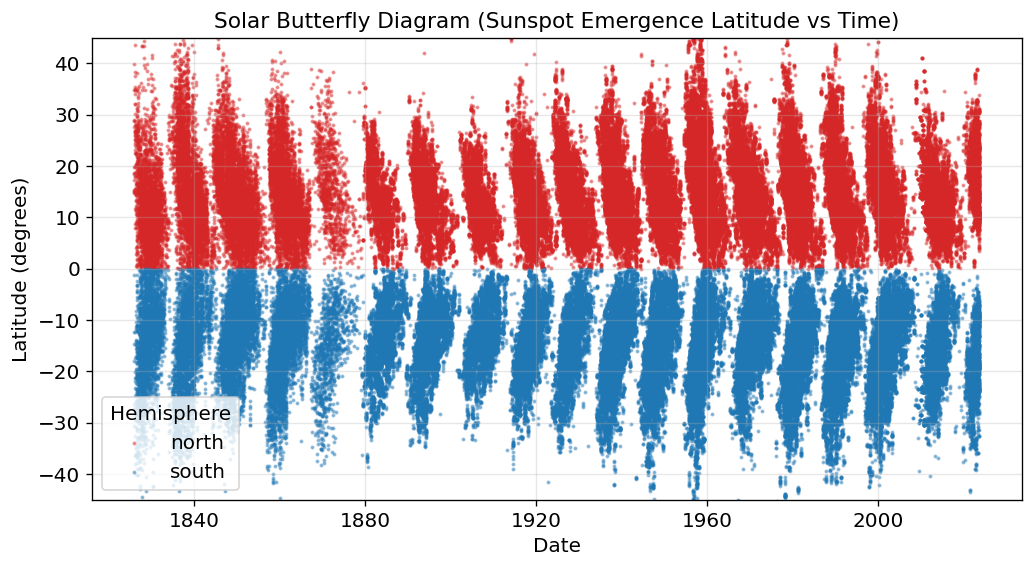

In [4]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


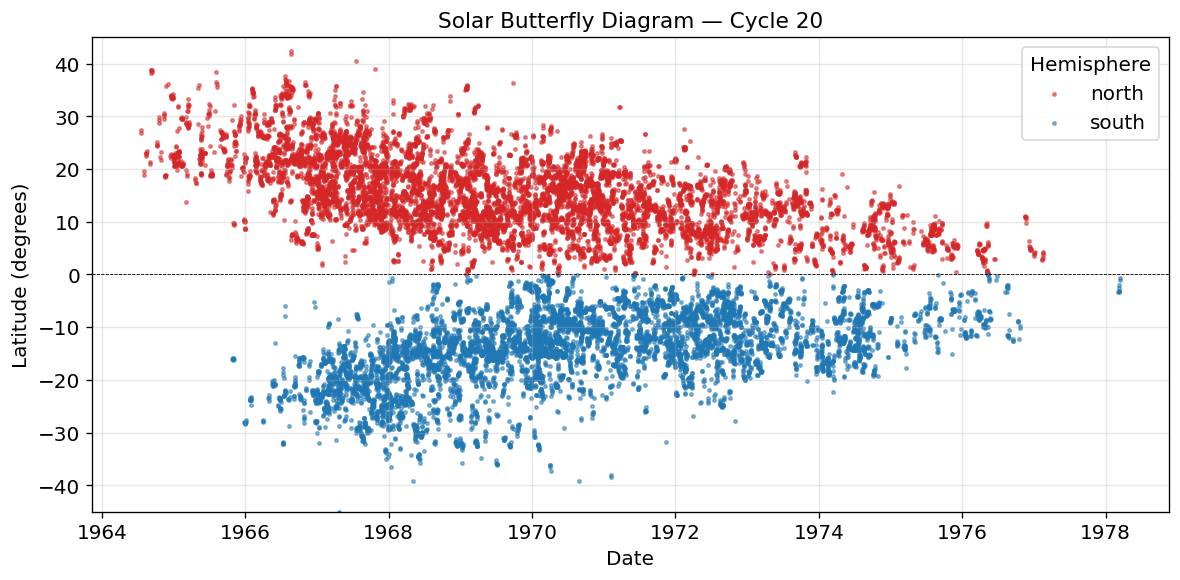

Cycle 20: 1964-07-17 → 1978-03-15
  N groups: 19,314
  Lat range: [-46.1°, 42.3°]


In [6]:
# Task 4: Visualize a single solar cycle
cycle_number = 20  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_1083/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


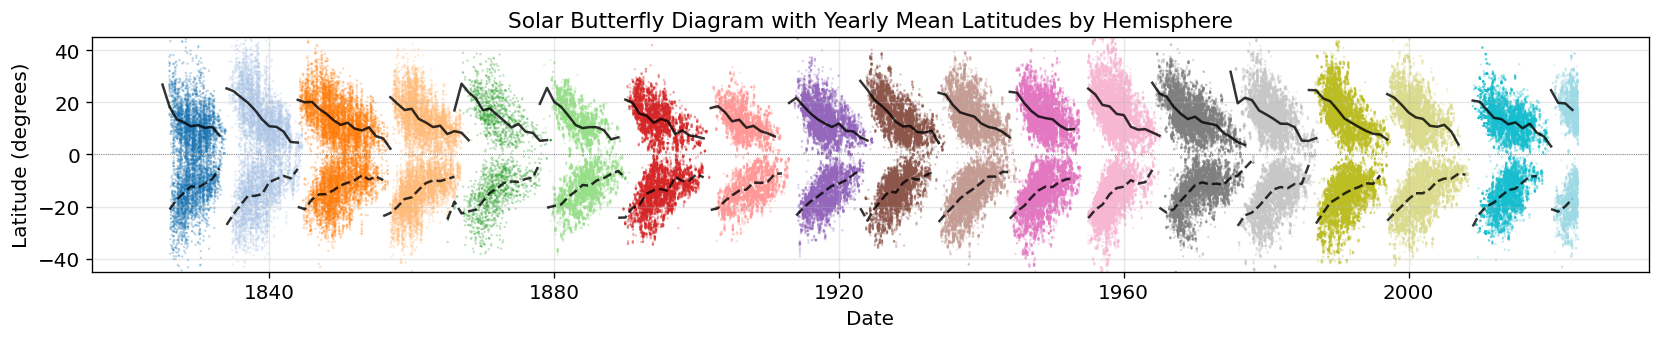

In [7]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]

    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black",
                linewidth=1.5, linestyle="-", alpha=0.8)

    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black",
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

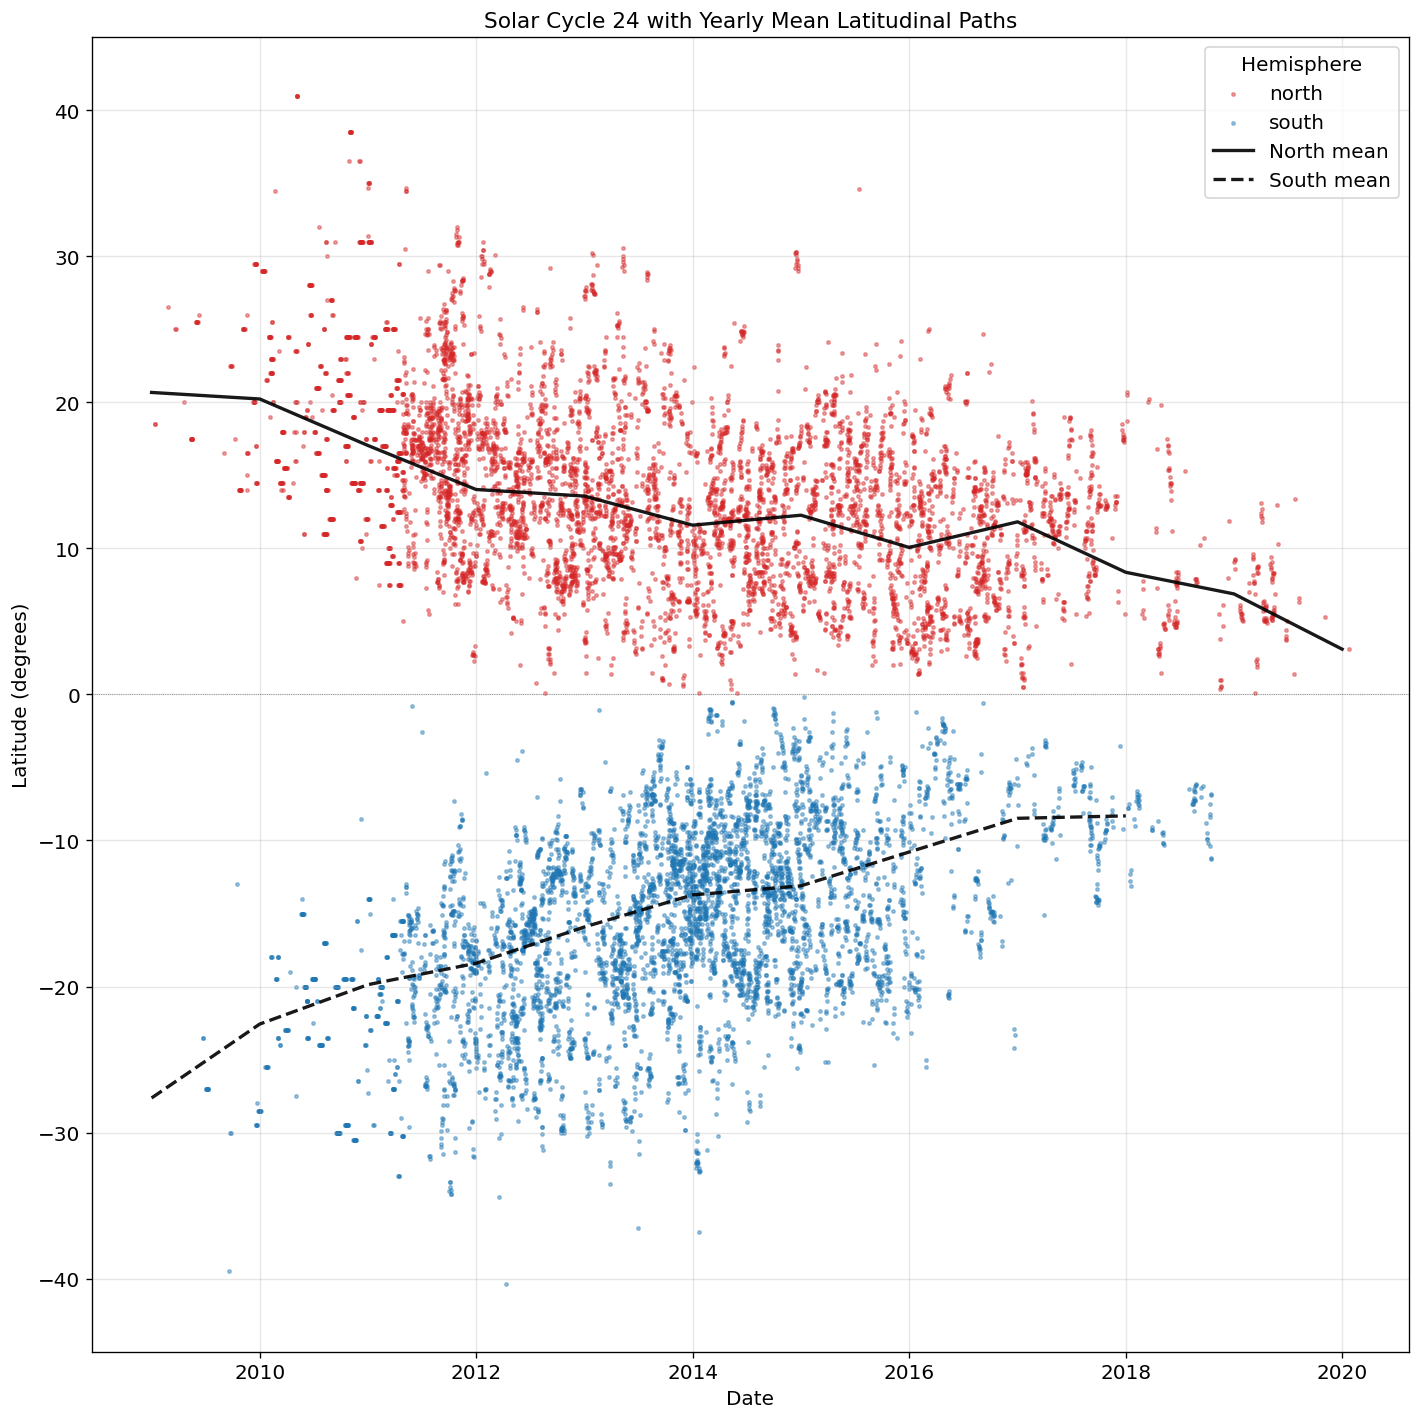

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [8]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black",
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black",
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


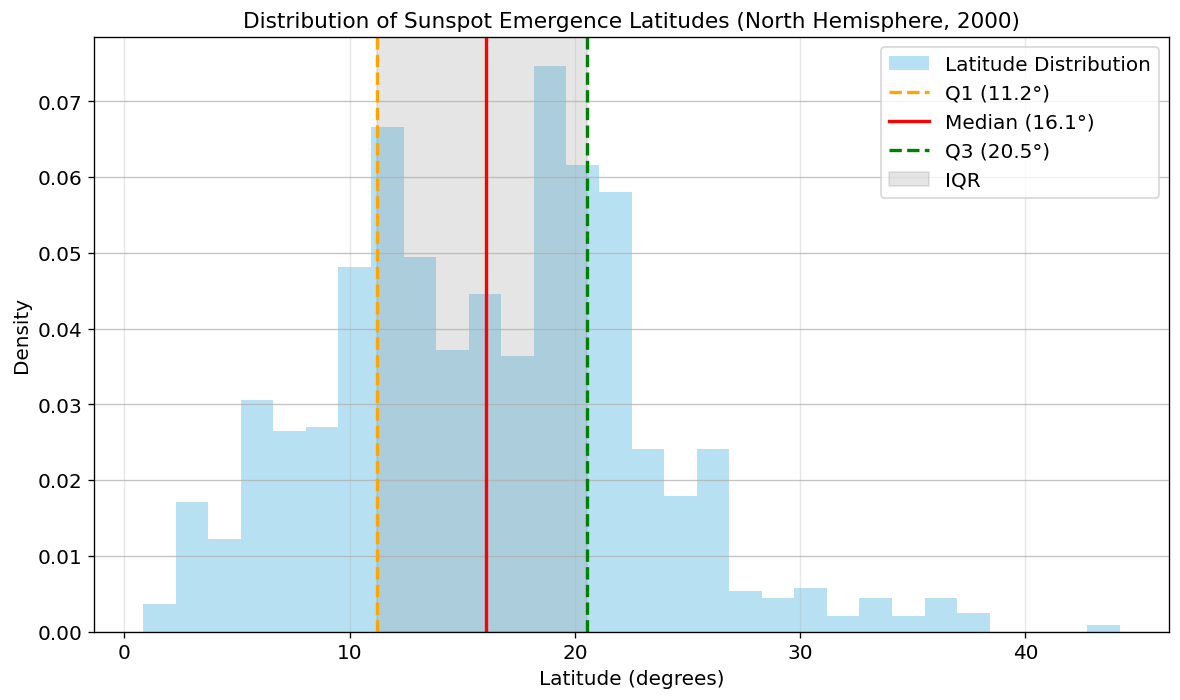

Selected Year: 2000, Selected Hemisphere: North
  Number of sunspots: 1694
  Min Latitude: 0.8°
  Max Latitude: 44.2°
  Q1: 11.2°
  Median: 16.1°
  Q3: 20.5°
  IQR: 9.3°


In [15]:
# Put your code for Task 6 here
import matplotlib.pyplot as plt
import numpy as np

# --- Task 6: Empirical Distribution for a Single Year and Hemisphere ---

selected_year = 2000  # Example year
selected_hemisphere = "north"  # Example hemisphere: "north" or "south"

# Filter data for the selected year and hemisphere
df_filtered = df[(df["date"].dt.year == selected_year) & (df["hemisphere"] == selected_hemisphere)]

# Get latitudes for the filtered data
latitudes = df_filtered["latitude"]

# Check if there is data for the selected year/hemisphere
if latitudes.empty:
    print(f"No data available for {selected_hemisphere} hemisphere in {selected_year}.")
else:
    # Calculate quartiles and median
    q1 = np.percentile(latitudes, 25)
    median = np.percentile(latitudes, 50)
    q3 = np.percentile(latitudes, 75)

    # Plotting the histogram
    fig, ax = plt.subplots(figsize=(10, 6))

    # Histogram with density normalization
    n, bins, patches = ax.hist(
        latitudes,
        bins=30, # You can adjust the number of bins
        density=True, # Normalize to density
        alpha=0.6,
        color="skyblue",
        label="Latitude Distribution"
    )

    # Add vertical lines for Q1, Median, Q3
    ax.axvline(q1, color="orange", linestyle="--", linewidth=2, label=f"Q1 ({q1:.1f}°)")
    ax.axvline(median, color="red", linestyle="-", linewidth=2, label=f"Median ({median:.1f}°)")
    ax.axvline(q3, color="green", linestyle="--", linewidth=2, label=f"Q3 ({q3:.1f}°)")

    # Shade the Interquartile Range (IQR)
    ax.axvspan(q1, q3, color="gray", alpha=0.2, label="IQR")

    ax.set_title(f"Distribution of Sunspot Emergence Latitudes ({selected_hemisphere.capitalize()} Hemisphere, {selected_year})")
    ax.set_xlabel("Latitude (degrees)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

    print(f"Selected Year: {selected_year}, Selected Hemisphere: {selected_hemisphere.capitalize()}")
    print(f"  Number of sunspots: {len(latitudes)}")
    print(f"  Min Latitude: {latitudes.min():.1f}°")
    print(f"  Max Latitude: {latitudes.max():.1f}°")
    print(f"  Q1: {q1:.1f}°")
    print(f"  Median: {median:.1f}°")
    print(f"  Q3: {q3:.1f}°")
    print(f"  IQR: {q3 - q1:.1f}°")

What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?

The shape has some skew, when changing the hemisphere it is a mirror image of the other. As the year changes it shifts toward the equator. Sunspots happen at higher latitude early in the cycle and closer to the equator later in the cycle.

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


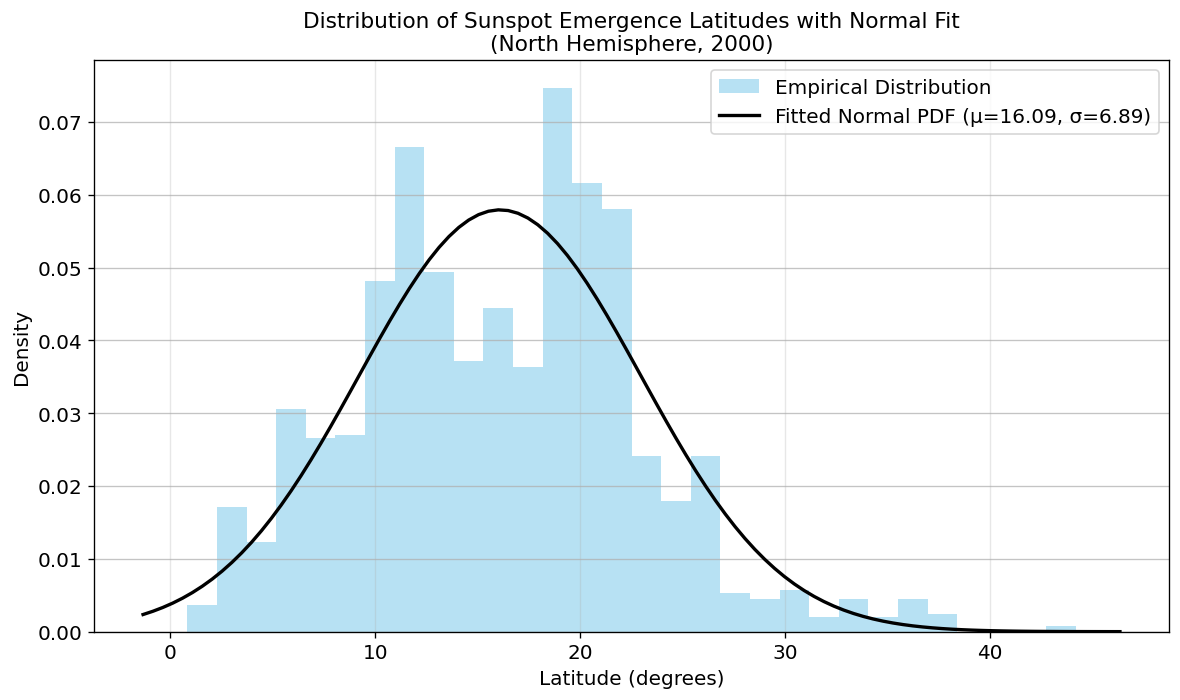

Fitted Normal Distribution Parameters for North Hemisphere, 2000:
  Mean (μ): 16.09°
  Standard Deviation (σ): 6.89°


In [16]:
# Put your code for Task 7 here
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Reuse the selected year and hemisphere from Task 6 (assuming it was executed)
# If not, set them explicitly here:
selected_year = 2000  # You can change this
selected_hemisphere = "north"  # You can change this

# Filter data for the selected year and hemisphere
df_filtered = df[(df["date"].dt.year == selected_year) & (df["hemisphere"] == selected_hemisphere)]
latitudes = df_filtered["latitude"]

if latitudes.empty:
    print(f"No data available for {selected_hemisphere} hemisphere in {selected_year} to fit a distribution.")
else:
    # Fit a Normal distribution to the data
    mu, sigma = norm.fit(latitudes)

    # Plotting the histogram (from Task 6)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(
        latitudes,
        bins=30, # Use the same number of bins as Task 6
        density=True, # Normalize to density
        alpha=0.6,
        color="skyblue",
        label="Empirical Distribution"
    )

    # Plot the PDF of the fitted Normal distribution
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    ax.plot(x, p, 'k', linewidth=2, label=f"Fitted Normal PDF (μ={mu:.2f}, σ={sigma:.2f})")

    ax.set_title(f"Distribution of Sunspot Emergence Latitudes with Normal Fit\n({selected_hemisphere.capitalize()} Hemisphere, {selected_year})")
    ax.set_xlabel("Latitude (degrees)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

    print(f"Fitted Normal Distribution Parameters for {selected_hemisphere.capitalize()} Hemisphere, {selected_year}:")
    print(f"  Mean (μ): {mu:.2f}°")
    print(f"  Standard Deviation (σ): {sigma:.2f}°")


Its fits relatively well. A Normal distribution is not the perfect fit because sunspots have skewness which Normal distribution is perfectly symmertrric. As it closer to the center it might be a good fit, but as it nears the tail it could underestimate the density and over estimate it on the toher side. In the Gaussian Normal distribution, there are two parameters mean and standart deviation. The mean is the avrg latitude of sunspot emergence based on the year and hemisphere. The standard devidation is the typical distance from the mean. So a larger SD means that sunspots emerge over aa wide range of latitudes.

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.




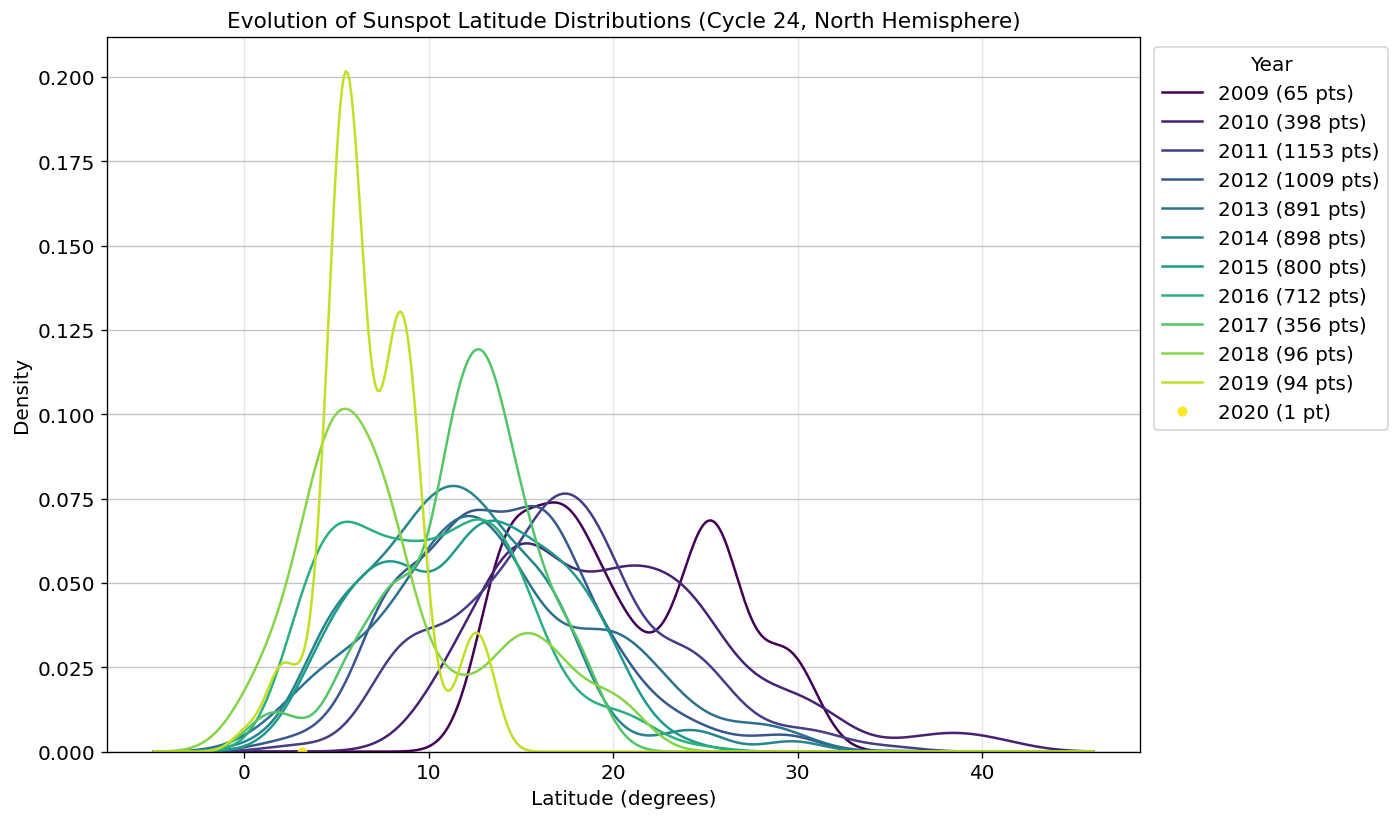

Selected Cycle: 24, Selected Hemisphere: North
Years in cycle: 2009 - 2020
Total sunspots in this selection: 6,473


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.cm as cm

# --- Task 8: Distribution Evolution Through a Solar Cycle ---

cycle_number = 24  # As discussed, we'll use Cycle 24
selected_hemisphere = "north"  # We'll start with the Northern Hemisphere

# Filter data for the selected cycle and hemisphere
df_cycle_hemi = df[(df["CYCLE"] == cycle_number) & (df["hemisphere"] == selected_hemisphere)].copy()

if df_cycle_hemi.empty:
    print(f"No data available for Cycle {cycle_number} in the {selected_hemisphere} hemisphere.")
else:
    # Get unique years in the selected cycle
    df_cycle_hemi["year"] = df_cycle_hemi["date"].dt.year
    years_in_cycle = sorted(df_cycle_hemi["year"].unique())

    fig, ax = plt.subplots(figsize=(12, 7))

    # Generate a colormap for years
    cmap = plt.colormaps["viridis"](np.linspace(0, 1, len(years_in_cycle))) # Fix: Updated to recommended colormap access

    # Define a range for KDE evaluation
    # Use the min/max latitude for the entire cycle/hemisphere, with some padding
    min_lat = df_cycle_hemi["latitude"].min() - 5
    max_lat = df_cycle_hemi["latitude"].max() + 5
    x_kde = np.linspace(min_lat, max_lat, 500)

    for i, year in enumerate(years_in_cycle):
        latitudes_year = df_cycle_hemi[df_cycle_hemi["year"] == year]["latitude"]

        if len(latitudes_year) > 1: # KDE requires at least 2 data points
            # Compute KDE
            kde = gaussian_kde(latitudes_year, bw_method=0.3) # bw_method can be adjusted
            pdf_values = kde(x_kde)

            # Plot KDE
            ax.plot(x_kde, pdf_values, color=cmap[i], label=f'{year} ({len(latitudes_year)} pts)') # Fix: Use cmap as an array
        elif len(latitudes_year) == 1:
            # If only one point, plot a small dot at its latitude
            ax.plot(latitudes_year.iloc[0], 0, 'o', color=cmap[i], markersize=5, label=f'{year} ({len(latitudes_year)} pt)')

    ax.set_title(f"Evolution of Sunspot Latitude Distributions (Cycle {cycle_number}, {selected_hemisphere.capitalize()} Hemisphere)")
    ax.set_xlabel("Latitude (degrees)")
    ax.set_ylabel("Density")
    ax.legend(title="Year", loc="upper right", bbox_to_anchor=(1.25, 1))
    ax.grid(axis='y', alpha=0.75)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

    print(f"Selected Cycle: {cycle_number}, Selected Hemisphere: {selected_hemisphere.capitalize()}")
    print(f"Years in cycle: {years_in_cycle[0]} - {years_in_cycle[-1]}")
    print(f"Total sunspots in this selection: {len(df_cycle_hemi):,}")

The distritbution shifts to the equator as the solar cycle progresses.

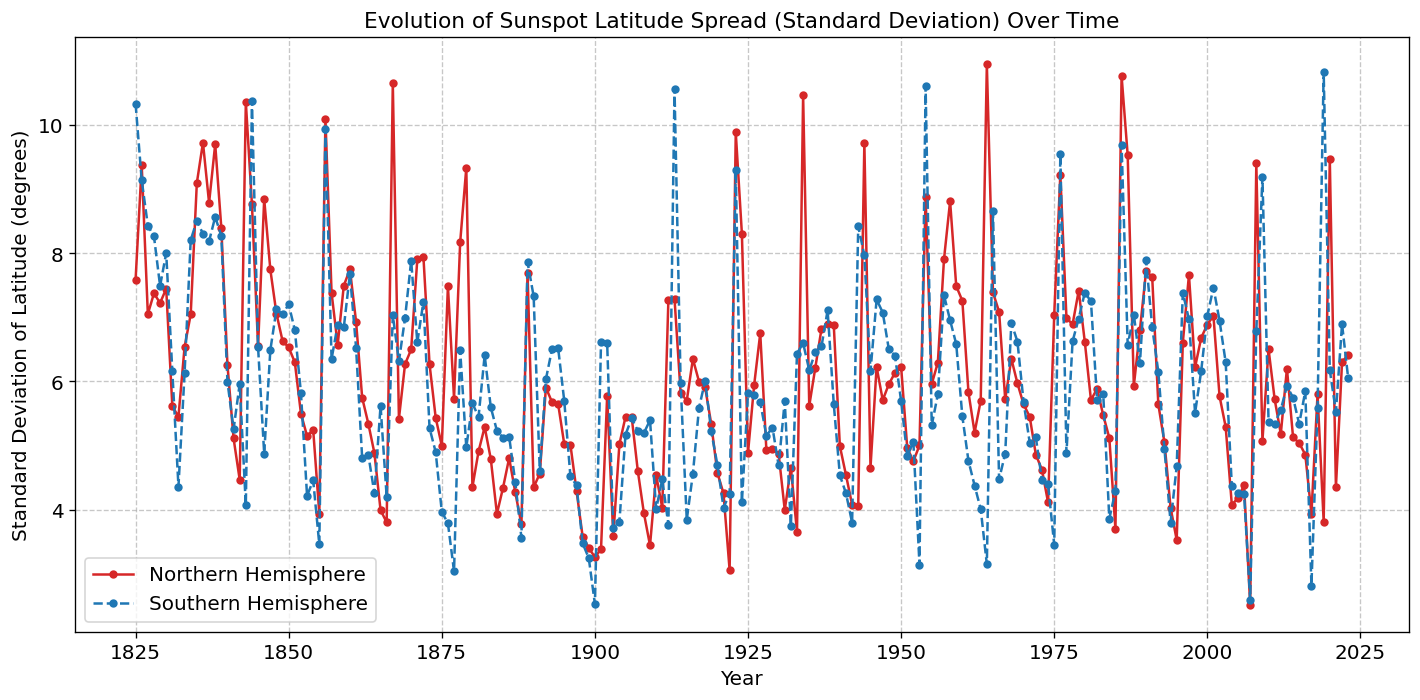

Calculated latitude spread (standard deviation) for each year and hemisphere.


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure 'year' column is available
if 'year' not in df.columns:
    df['year'] = df['date'].dt.year

# Calculate standard deviation of latitude for each year and hemisphere
# Filter out groups with less than 2 data points, as std dev is undefined for 1 point
spread_data = df.groupby(['year', 'hemisphere'])['latitude'].std().reset_index()
spread_data.rename(columns={'latitude': 'std_latitude'}, inplace=True)

# Plotting the evolution of spread
fig, ax = plt.subplots(figsize=(12, 6))

# Plot for Northern Hemisphere
df_north_spread = spread_data[spread_data['hemisphere'] == 'north']
ax.plot(df_north_spread['year'], df_north_spread['std_latitude'],
        label='Northern Hemisphere', color='tab:red', marker='o', markersize=4)

# Plot for Southern Hemisphere
df_south_spread = spread_data[spread_data['hemisphere'] == 'south']
ax.plot(df_south_spread['year'], df_south_spread['std_latitude'],
        label='Southern Hemisphere', color='tab:blue', marker='o', markersize=4, linestyle='--')

ax.set_title('Evolution of Sunspot Latitude Spread (Standard Deviation) Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Standard Deviation of Latitude (degrees)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Calculated latitude spread (standard deviation) for each year and hemisphere.")

This plot shows how the standard deviation of sunspot latitudes has changed over the years for both the Northern and Southern Hemispheres. A higher standard deviation indicates a wider spread of sunspots across latitudes in that year, while a lower value suggests sunspots are clustered more tightly around the mean latitude.

Using this we can see that the SD changes over time